**This classifeir uses TF-IDF**


In [1]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch import nn
import tqdm
from timeit import default_timer as timer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import  TfidfVectorizer
from scipy import sparse
# from malware_supcons import MalDectModel
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import seaborn as sns

**load data**


In [2]:
#X= pd.read_csv("D:\\temp dataset\\malware_api_class-master\\malware_api_class-master\\all_analysis_data.txt",  nrows=3800, header=None)
Y = pd.read_csv("D:\\temp dataset\\malware_api_class-master\\malware_api_class-master\\labels.csv" ,header = None)
X = sparse.load_npz("tf_idf_embedding_33.npz")

np.random.seed(42)
# random_indices = np.random.choice(len(X), 4000, replace=False)

# X = X.iloc[random_indices].reset_index(drop= True)
# Y = Y.iloc[random_indices].reset_index(drop=True)

import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

if device == 'cuda':
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())


Device: cpu


In [14]:
import torch
print(torch.__version__)
print(torch.version.cuda)


2.9.1+cpu
None


**Pre Process**

In [4]:



vectorizer = TfidfVectorizer(ngram_range=(3, 3),smooth_idf=True, norm="l2", sublinear_tf=True,
                             max_df=.9,)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=.4
                                                    , random_state=42, shuffle=True)

X_test, X_validation, y_test, y_validation = train_test_split(X_temp, y_temp, test_size=.5
                                                    , random_state=42, shuffle=True)




vocab = set()

y_train[0].apply(lambda x : vocab.add(x))

vocab_idx = {}
for index, malware in enumerate(vocab):
    vocab_idx[malware] = index

def convert_to_num(data):
    return vocab_idx.get(data)
y_train[0] = y_train[0].apply(lambda x : convert_to_num(x))
y_test[0] = y_test[0].apply(lambda x : convert_to_num(x))
y_validation[0] = y_validation[0].apply(lambda x : convert_to_num(x))





y_test = torch.tensor(y_test.values, dtype=torch.long)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_validation = torch.tensor(y_validation.values, dtype=torch.long)







**Dataset**

In [5]:
writer = SummaryWriter("runs/experiments")



class ApiDataSet(Dataset):
    def __init__(self, data, labels):
        super().__init__()
        self.data = data
        self.labels = labels

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx].toarray()  # shape [input_size=278]
        y = self.labels[idx]
        x = torch.tensor(x, dtype= torch.float32)

        # Gaussian noise
        # Add seq_len=1 dimension
                 # [1, 278]

        return x, y



dataset_train = ApiDataSet(X_train, y_train)

data_loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)


dataset_test = ApiDataSet(X_test, y_test)

data_loader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)


dataset_validation = ApiDataSet(X_validation, y_validation)

data_loader_validation = DataLoader(dataset_validation, batch_size=32, shuffle=True)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

**Model**

In [6]:
class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))



class Classifier(nn.Module):
    def __init__(self, input_dim, num_Classes):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(in_features=input_dim, out_features=num_Classes)

    def forward(self, x):
        return self.fc(x)    


class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))
    

**Train and Test**

In [7]:
def train_step(model, classifier, loss_fn, optimizer, train_data_loader):
    model.eval()
    classifier.train()
    train_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    for (x, y ) in train_data_loader:

        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            output, [hidden, cell]  = model.lstm(x)
            features = hidden[-1]

        out = classifier(features)

        if len(y.shape) > 1 and y.shape[1] == 1:
          y = y.squeeze(1)
        elif len(y.shape) > 1:
          y = torch.argmax(y, dim=1)


        loss = loss_fn(out, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        
        
        probs = torch.softmax(out, dim=1)
        preds = probs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())
        all_probs.append(probs.cpu())  # positive class probabilities for AUC


    all_preds = torch.cat(all_preds).detach().numpy()
    all_labels = torch.cat(all_labels).detach().numpy()
    all_probs = torch.cat(all_probs).detach().numpy()

    print(all_preds[0])
    train_loss = train_loss / len(train_data_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_auc = roc_auc_score(all_labels, all_probs,multi_class='ovr', average='macro')
    train_prec = precision_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds,average='macro')
    return train_loss, train_acc,train_f1, train_auc, train_prec, train_recall


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch
from tqdm import tqdm

def test_step(model, classifier, loss_fn, validation_data_loader):
    model.eval()
    classifier.eval()  # classifier should be in eval mode for testing

    test_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for x, y in validation_data_loader:
        x, y = x.to(device), y.to(device)

        # Preprocess y for multi-class / single-class
        if len(y.shape) > 1 and y.shape[1] == 1:
            y = y.squeeze(1)
        elif len(y.shape) > 1:
            y = torch.argmax(y, dim=1)

        with torch.no_grad():
            output, [hidden, cell] = model.lstm(x)
            out = classifier(hidden[-1])
            loss = loss_fn(out, y)
            test_loss += loss.item()
            
            # Predictions and probabilities
            probs = torch.softmax(out, dim=1)

            preds = probs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())  # positive class probabilities for AUC

    # Concatenate all batches
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # Metrics
    validation_loss = test_loss / len(validation_data_loader)
    validation_acc = accuracy_score(all_labels, all_preds)
    validation_f1 = f1_score(all_labels, all_preds, average='micro')
    validation_auc = roc_auc_score(all_labels, all_probs,multi_class='ovr', average='macro')
    val_prec = precision_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds,average='macro')

    return validation_loss, validation_acc, validation_f1, validation_auc, val_prec, val_recall


def train(model, classifier, loss_fn, optimizer, train_data_loader, epochs, test_data_loader):
    val_loss, val_acc, val_f1, val_auc = 0, 0 , 0, 0 
    train_loss = 0


    val_acc_list, val_loss_list, vali_f1_list, val_auc_list,val_prec_list, val_rec_list = [], [], [], [], [], []
    train_acc_list, train_loss_list, train_f1_list, train_auc_list, train_prec_list, train_rec_list = [], [], [], [], [], []
    train_loss_list = []
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc, train_f1, train_auc, train_prec, train_rec= train_step(model=model, classifier=classifier, loss_fn=loss_fn, optimizer=optimizer,
                                train_data_loader=train_data_loader)
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)
        train_auc_list.append(train_auc)
        train_f1_list.append(train_f1)
        train_prec_list.append(train_prec)
        train_rec_list.append(train_rec)


        val_loss, val_acc, val_f1, val_auc, val_prec, val_recall = test_step(
            model=model, classifier=classifier, loss_fn=loss_fn, validation_data_loader=test_data_loader)
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)
        val_auc_list.append(val_auc)
        vali_f1_list.append(val_f1)
        val_prec_list.append(val_prec)
        val_rec_list.append(val_recall)


        print(
        f"Epoch: {epoch+1} | "
        f"train_loss: {train_loss:.4f} | "
        f"validation_loss: {val_loss:.4f} | "
        f"validation_acc: {val_acc:.4f} | "
        f"validation_F1: {val_f1:.4f} | "
        f"validation_AUC: {val_auc:.4f} | "
        f"validation_Precision: {val_prec:.4f} | "
        f"validation_Recall: {val_recall:.4f}"
    )

        # # log scalars (to see curves)
        # writer.add_scalar("Loss/train", train_loss, epoch)
        # writer.add_scalar("Loss/test", val_loss, epoch)
        # writer.add_scalar("Metrics/accuracy", val_acc, epoch)
        # writer.add_scalar("Metrics/f1", val_f1, epoch)
        # writer.add_scalar("Metrics/auc", val_auc, epoch)

    # after training: log hparams + final metrics
    hparams = {
        "ngram_min": 3,
        "ngram_max": 4,
        "learning_rate": 1e-4,
    }

    metrics = {
        "final_train_loss": train_loss,
        "final_test_loss": val_loss,
        "final_test_acc": val_acc,
        "final_test_f1": val_f1,
        "final_test_auc": val_auc,
    }

    # writer.add_hparams(hparams, metrics)
    # writer.close()

    return train_loss_list,train_acc_list,train_f1_list, train_auc_list, train_prec_list, train_rec_list,val_loss_list, val_acc_list, vali_f1_list, val_auc_list, val_prec_list, val_rec_list

    

**visualize**

In [8]:
def visualize(epochs, train_loss_list,train_acc_list,train_f1_list,train_auc_list,train_prec_list, train_rec_list ,val_loss_list, val_acc_list, vali_f1_list, val_auc_list,val_prec_list, val_rec_list):
    fix, axes = plt.subplots(3, 2, figsize = (18, 10))

    
    axes[0][0].plot(range(1, epochs +1), train_loss_list, color = '#1f77b4', label = "train loss", linewidth = 2)
    axes[0][0].plot(range(1, epochs +1), val_loss_list, color = "#ff7f0e", label = "validation loss", linewidth = 2)
    axes[0][0].set_title("validation/train loss")
    axes[0][0].set_ylabel("Loss")
    axes[0][0].set_xlabel("epoch")
    axes[0][0].legend()
    
    
    axes[0][1].plot(range(1, epochs +1), val_acc_list, color = "#1f77b4", label ="train accuracy",linewidth = 2)
    axes[0][1].plot(range(1, epochs +1), train_acc_list, color = "#ff7f0e", label = "validation accuracy",linewidth = 2)
    axes[0][1].set_title("Validation accuracy")
    axes[0][1].set_ylabel("Accuracy")
    axes[0][1].set_xlabel("epoch")
    axes[0][1].legend()

    
    axes[1][0].plot(range(1, epochs +1), vali_f1_list, color = "#1f77b4",label = "train f1-score", linewidth = 2)
    axes[1][0].plot(range(1, epochs +1), train_f1_list, color = "#ff7f0e", label = "validation f1-score",linewidth = 2)
    axes[1][0].set_title("Validation f1 score")
    axes[1][0].set_ylabel("F1 score")
    axes[1][0].set_xlabel("epoch")
    axes[1][0].legend()

    
    axes[1][1].plot(range(1, epochs +1), val_auc_list, color = "#1f77b4",label="train AUC" ,linewidth = 2)
    axes[1][1].plot(range(1, epochs +1), train_auc_list, color = "#ff7f0e", label = "validation AUC",linewidth = 2)
    axes[1][1].set_title("Validation AUC")
    axes[1][1].set_ylabel("AUC")
    axes[1][1].set_xlabel("epoch")
    axes[1][1].legend()

 # Plot Precision
    axes[2][0].plot(range(1, epochs + 1), val_prec_list, color="#1f77b4", label="validation precision", linewidth=2)
    axes[2][0].plot(range(1, epochs + 1), train_prec_list, color="#ff7f0e", label="train precision", linewidth=2)
    axes[2][0].set_title("Precision")
    axes[2][0].set_ylabel("Precision")
    axes[2][0].set_xlabel("Epoch")
    axes[2][0].legend()

    # Plot Recall
    axes[2][1].plot(range(1, epochs + 1), val_rec_list, color="#1f77b4", label="validation recall", linewidth=2)
    axes[2][1].plot(range(1, epochs + 1), train_rec_list, color="#ff7f0e", label="train recall", linewidth=2)
    axes[2][1].set_title("Recall")
    axes[2][1].set_ylabel("Recall")
    axes[2][1].set_xlabel("Epoch")
    axes[2][1].legend()


    plt.tight_layout()


**Final Test**

In [9]:
def final_evaluate(model, classifier, loss_fn, test_data_loader):
    model.eval()
    classifier.eval()  # classifier should be in eval mode for testing

    test_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for x, y in test_data_loader:
        x, y = x.to(device), y.to(device)

        # Preprocess y for multi-class / single-class
        if len(y.shape) > 1 and y.shape[1] == 1:
            y = y.squeeze(1)
        elif len(y.shape) > 1:
            y = torch.argmax(y, dim=1)

        with torch.no_grad():
            output, [hidden, cell] = model.lstm(x)
            out = classifier(hidden[-1])
            loss = loss_fn(out, y)
            test_loss += loss.item()

            # Predictions and probabilities
            
            probs = torch.softmax(out, dim=1)
            preds = probs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
            all_probs.append(probs.cpu())  # positive class probabilities for AUC

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()
# Metrics
    test_loss = test_loss / len(test_data_loader)
    test_acc = accuracy_score(all_labels, all_preds)

    # F1
    test_f1_macro = f1_score(all_labels, all_preds, average='macro')
    test_f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    # Precision
    test_prec_macro = precision_score(all_labels, all_preds, average='macro')
    test_prec_weighted = precision_score(all_labels, all_preds, average='weighted')

    # Recall
    test_rec_macro = recall_score(all_labels, all_preds, average='macro')
    test_rec_weighted = recall_score(all_labels, all_preds, average='weighted')

    # AUC (multi-class)
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    cm = confusion_matrix(all_labels, all_preds)
    return test_loss, test_acc, test_f1_macro, test_f1_weighted, test_prec_macro, test_prec_weighted, test_rec_macro, test_rec_weighted, test_auc, cm


**Main**

In [10]:
from tqdm.auto import tqdm


if __name__ == "__main__":

    torch.manual_seed(42)
    model  = MalDectModel(input_size=X_train.shape[1], 
                          hidden_dim=128, projection_dim=128)
    
    
    model_save_path = "F:\\university\\projects\\malware_api_detection_using_supcons\\mal-api-2019\\supconModel_v2_33.pth"
    model.load_state_dict(torch.load(f=model_save_path))


    epochs = 100
    classifier = Classifier(input_dim=128,num_Classes=8)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(params=classifier.parameters())


    train_loss_list, train_acc_list, train_f1_list, train_auc_list, \
    train_prec_list, train_rec_list, \
    val_loss_list, val_acc_list, vali_f1_list, val_auc_list, \
    val_prec_list, val_rec_list = train(
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        train_data_loader=data_loader_train,
        epochs=epochs,
        classifier=classifier,
        test_data_loader=data_loader_validation
    )

   

  0%|          | 0/100 [00:00<?, ?it/s]

1
Epoch: 1 | train_loss: 1.6814 | validation_loss: 1.3553 | validation_acc: 0.7433 | validation_F1: 0.7433 | validation_AUC: 0.9559 | validation_Precision: 0.7991 | validation_Recall: 0.7332
1
Epoch: 2 | train_loss: 1.2027 | validation_loss: 1.0427 | validation_acc: 0.7883 | validation_F1: 0.7883 | validation_AUC: 0.9658 | validation_Precision: 0.8152 | validation_Recall: 0.7791
1
Epoch: 3 | train_loss: 0.9885 | validation_loss: 0.8808 | validation_acc: 0.8129 | validation_F1: 0.8129 | validation_AUC: 0.9716 | validation_Precision: 0.8335 | validation_Recall: 0.8028
4
Epoch: 4 | train_loss: 0.8625 | validation_loss: 0.7820 | validation_acc: 0.8340 | validation_F1: 0.8340 | validation_AUC: 0.9753 | validation_Precision: 0.8501 | validation_Recall: 0.8257
6
Epoch: 5 | train_loss: 0.7792 | validation_loss: 0.7094 | validation_acc: 0.8509 | validation_F1: 0.8509 | validation_AUC: 0.9786 | validation_Precision: 0.8652 | validation_Recall: 0.8424
4
Epoch: 6 | train_loss: 0.7169 | validation_

Test loss: 0.17247030958533288 | Test acc: 0.9627023223082336 | Test F1 macro: 0.9632054537943932 | Test F1 weighted: 0.9627872835214213 | Test Precision macro: 0.9636358851328501 | Test Precision weighted: 0.9632178258140426 | Test Recall macro: 0.9630773356471563 | Test Recall weighted: 0.9627023223082336 | Test AUC: 0.9966962108435148
Confusion Matrix:
[[194   0   0   2   0   0   0   1]
 [  0 208   2   2   0   0   1   1]
 [  0   0 154   3   0   0   1   3]
 [  2   1   2 175   1   0   0   3]
 [  0   0   0   3 189   2   0   0]
 [  0   1   0   1   0  62   0   0]
 [  1   7   0   4   1   0 195   0]
 [  0   5   1   0   1   0   1 191]]


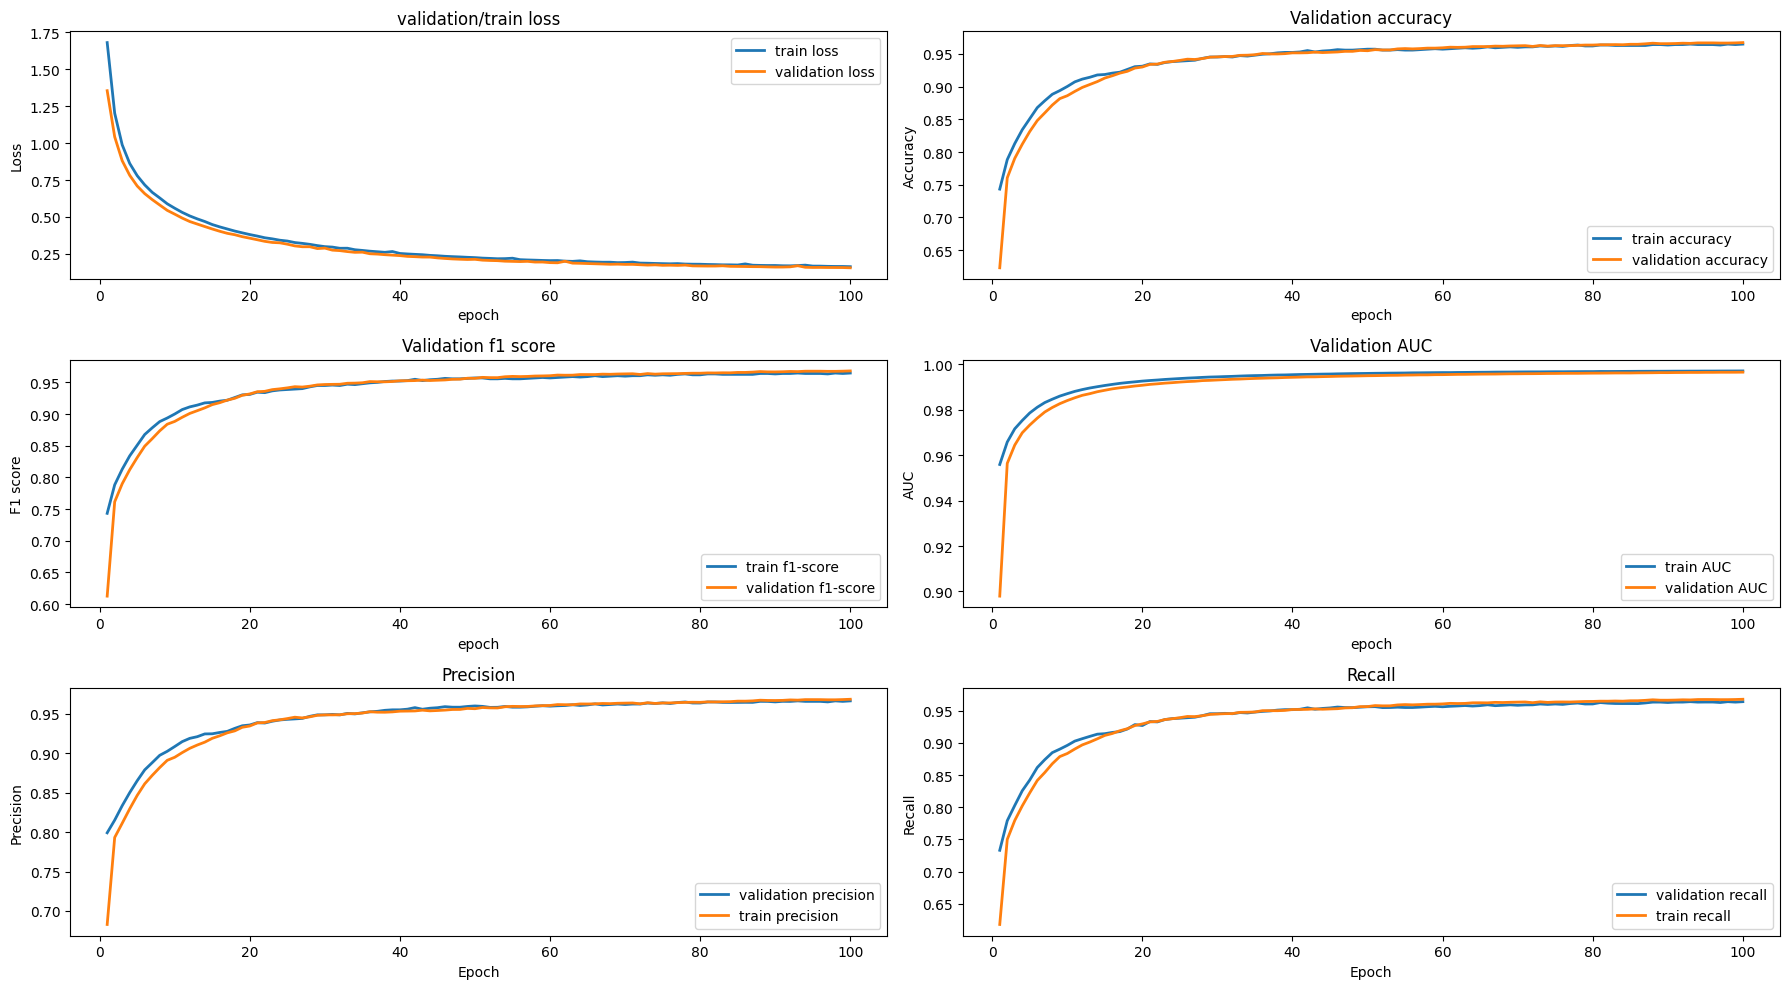

In [11]:
visualize(
    epochs, 
    train_loss_list, train_acc_list, train_f1_list, train_auc_list, train_prec_list, train_rec_list,
    val_loss_list, val_acc_list, vali_f1_list, val_auc_list, val_prec_list, val_rec_list
)
test_loss, test_acc, test_f1_macro, test_f1_weighted, \
test_prec_macro, test_prec_weighted, \
test_rec_macro, test_rec_weighted, \
test_auc, cm = final_evaluate(model, classifier, loss_fn, data_loader_test)
print(f"Test loss: {test_loss} | "
      f"Test acc: {test_acc} | "
      f"Test F1 macro: {test_f1_macro} | "
      f"Test F1 weighted: {test_f1_weighted} | "
      f"Test Precision macro: {test_prec_macro} | "
      f"Test Precision weighted: {test_prec_weighted} | "
      f"Test Recall macro: {test_rec_macro} | "
      f"Test Recall weighted: {test_rec_weighted} | "
      f"Test AUC: {test_auc}")

print("Confusion Matrix:")
print(cm)




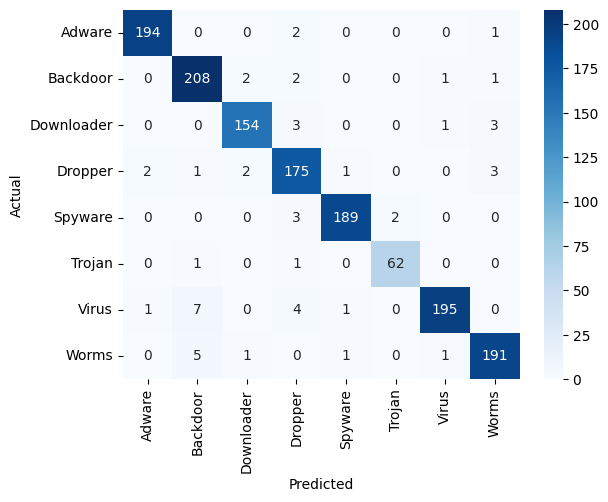

In [12]:
classes = ['Adware', 'Backdoor', 'Downloader', 'Dropper', 'Spyware', 'Trojan', 'Virus', 'Worms']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()